Welcome to our interactive notebook presenting the results of our paper !

The first cell below reproduced the correlations from the paper (Table 4-5, also A2-A3).

The next one generates plots to visualize the differences between global correlation and per-organism correlation.

In [1]:
from Bio import SeqIO
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error as rmse
from scipy.stats import pearsonr

# choose models to include

models = [
    'PRIME',
    'TemStaPro',
    'PPTStab',
    'DeepSTABp',
    'TemBERTure',
    'ThermoFormer',
    'TmProt',
    'FINE_650M_FULL_MELTOME',
    'FINE_650M_FLIP',
    'FINE_650M_NO_INT',
    'FINE_3B_NO_INT'
]

# Choose TPP test sets
groups_tpp = [
    '1_TEST',
    '3_REVERSED',
    '4_SHUFFLED',
    '2_FIRST_100',
]

# Choose DSC test sets
groups_dsc = [
    'scoop',
    'nanomelt',
    'csp',
    'petases',
]


# Make dict for accessing protein information easily, see cell below for example
big_tpp_file = SeqIO.parse('./data/TPP/tpp.fasta', "fasta")
big_fasta_labels = dict()

for rec in big_tpp_file:
    d = {_n.split('=')[0]: _n.split('=')[-1] for _n in rec.name.split(';')}
    d['tm'] = float(d['tm'])
    d['seq'] = str(rec._seq)  # remove str(..) if you want access to SeqIO.Seq methods
    big_fasta_labels[d['protein_id']] = d

dsc_labels = dict()

for dsc_file in groups_dsc:
    data = SeqIO.parse(f'./data/DSC/{dsc_file}.fasta', "fasta")
    dsc_labels[dsc_file] = dict()
    for rec in data:
        d = {_n.split('=')[0]: _n.split('=')[-1] for _n in rec.name.split(';')}
        d['tm'] = float(d['tm'])
        d['seq'] = str(rec._seq)
        dsc_labels[dsc_file][d['protein_id']] = d

In [2]:
# Example TPP 

big_fasta_labels['A0A061ACF5_fbl-1']

{'protein_id': 'A0A061ACF5_fbl-1',
 'up_id': 'A0A061ACF5',
 'mapped_id': 'A0A061ACF5',
 'mapped_parcID': 'NaN',
 'sp': 'C.elegans',
 'set': 'Meltome',
 'split': 'train',
 'tm': 49.459,
 'seq': 'MRICFLLLAFLVAETFANELTRCCAGGTRHFKNSNTCSSIKSEGTSMTCQRAASICCLRSLLDNACDSGTDIAKEEESCPSNINILGGGLKKECCDCCLLAKDLLNRNEPCVAPVGFSAGCLRSFNKCCNGDIEITHASEIITGRPLNDPHVLHLGDRCASSHCEHLCHDRGGEKVECSCRSGFDLAPDGMACVDIDECATLMDDCLESQRCLNTPGSFKCIRTLSCGTGYAMDSETERCRDVDECNLGSHDCGPLYQCRNTQGSYRCDAKKCGDGELQNPMTGECTSITCPNGYYPKNGMCNDIDECVTGHNCGAGEECVNTPGSFRCQQKGNLCAHGYEVNGATGFCEDVNECTTGIAACEQKCVNIPGSYQCICDRGFALGPDGTKCEDIDECSIWAGSGNDLCMGGCINTKGSYLCQCPPGYKIQPDGRTCVDVDECAMGECAGSDKVCVNTLGSFKCHSIDCPTNYIHDSLNKNQIADGYSCIKVCSTEDTECLGNHTREVLYQFRAVPSLKTIISPIEVSRIVTHMGVPFSVDYNLDYVGQRHFRIVQERNIGIVQLVKPISGPTVETIKVNIHTKSRTGVILAFNEAIIEISVSKYPF'}

In [3]:
# Example DSC

dsc_labels['petases']['ACV09511']

{'protein_id': 'ACV09511',
 'tm': 42.4,
 'seq': 'ADTPYERGPNPSESLIEQRRGNYDIAQRSISRFSSDGFRNGTIYYPTDTSDGKFGVIAISPGYTAGESSIAWLGSRIASFGFVVVTINTTTRYDQPRQRSTQLLAALDHAMNDSVVGPLIDPERQAVMGHSMGGGGALQAAESRPEIDAVVALTPWNLKKNWDGVDAATLIIGAERDTVASVRTHSIPFYESLTQAEQRGYLELRGASHFAPNVSNTTIAKYSIAWMKRYLDNDDRYDQFLNPGPAVGYASGVSDYRLQ'}

In [4]:
# check results
import warnings

warnings.filterwarnings('ignore')  # For TemStaPro on 'nanomelt' because array is constant (correlation is NaN)

log_NA = False  # Only for TmProt, 25 sequences do not pass conditions proper to the predictor (sequence size, 'X' amino acids, ...)


for mod in models:
    print(mod)
    for group in groups_tpp + groups_dsc:
        result = pd.read_csv(f'./results/{mod}/{group}.csv') # fetch result file
        if log_NA:
            NAs = result[result['pred'].isna()] # check for NAs (only TmProt)
            print(f'\tWarning: {len(NAs)} NaN in {mod} ({group}): {NAs['name'].tolist()}')
        result = result.dropna()
        predictions = result['pred']
        labels = result['exp_tm']

        # make dict for easy acces
        name_2_label = result.set_index('name').to_dict()['exp_tm']
        name_2_pred = result.set_index('name').to_dict()['pred']

        # print predictions per group
        corr, p = pearsonr(predictions, labels)
        n_rmse = rmse(predictions, labels) / np.std(labels)
        print(f"\t{group:12s}: pearson = {str(round(corr, 2)):5s}, n_rmse = {str(round(n_rmse, 2)):5s}")
    print()

PRIME
	1_TEST      : pearson = 0.84 , n_rmse = 1.62 
	3_REVERSED  : pearson = 0.58 , n_rmse = 2.18 
	4_SHUFFLED  : pearson = 0.36 , n_rmse = 2.43 
	2_FIRST_100 : pearson = 0.73 , n_rmse = 1.82 
	scoop       : pearson = 0.61 , n_rmse = 1.96 
	nanomelt    : pearson = 0.1  , n_rmse = 3.11 
	csp         : pearson = 0.54 , n_rmse = 3.39 
	petases     : pearson = 0.18 , n_rmse = 2.95 

TemStaPro
	1_TEST      : pearson = 0.68 , n_rmse = 1.34 
	3_REVERSED  : pearson = 0.48 , n_rmse = 1.54 
	4_SHUFFLED  : pearson = 0.3  , n_rmse = 1.63 
	2_FIRST_100 : pearson = 0.39 , n_rmse = 1.42 
	scoop       : pearson = 0.61 , n_rmse = 1.68 
	nanomelt    : pearson = nan  , n_rmse = 3.63 
	csp         : pearson = 0.78 , n_rmse = 1.94 
	petases     : pearson = 0.1  , n_rmse = 2.59 

PPTStab
	1_TEST      : pearson = 0.77 , n_rmse = 0.67 
	3_REVERSED  : pearson = 0.65 , n_rmse = 0.78 
	4_SHUFFLED  : pearson = 0.58 , n_rmse = 0.87 
	2_FIRST_100 : pearson = 0.66 , n_rmse = 0.76 
	scoop       : pearson = 0.46 , n_

TemBERTure (lost 0 due to NA)


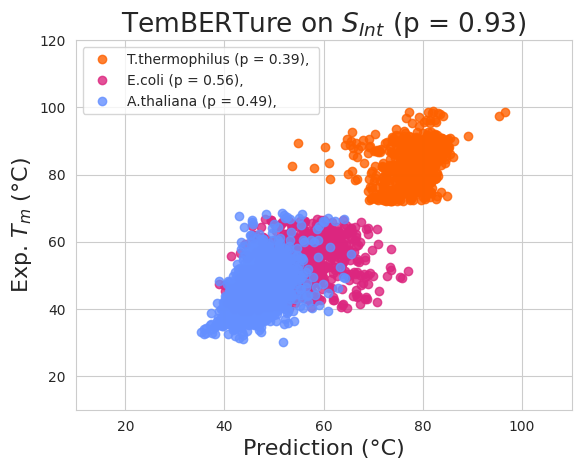

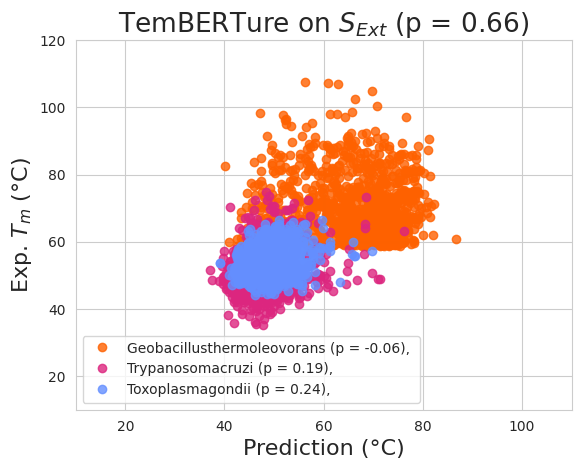

TmProt (lost 25 due to NA)


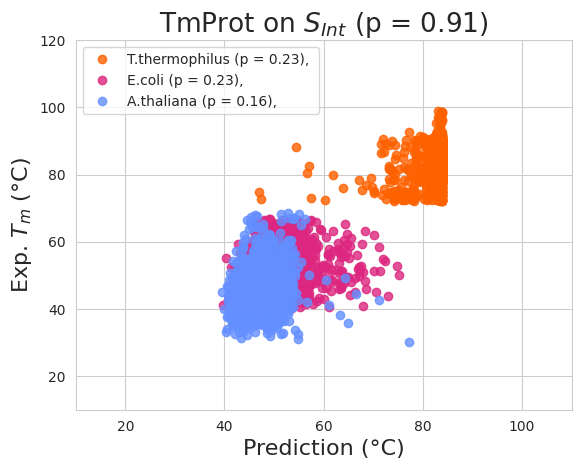

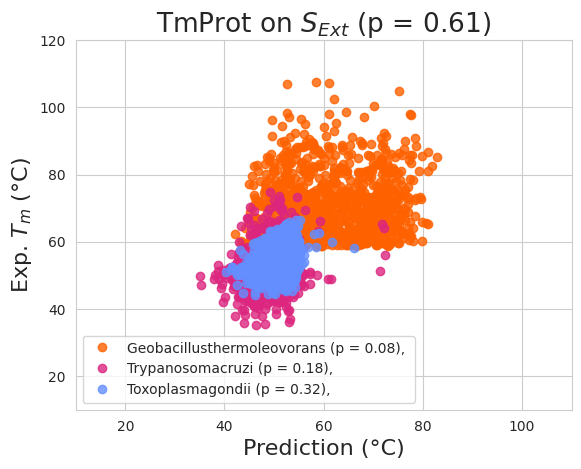

PRIME (lost 0 due to NA)


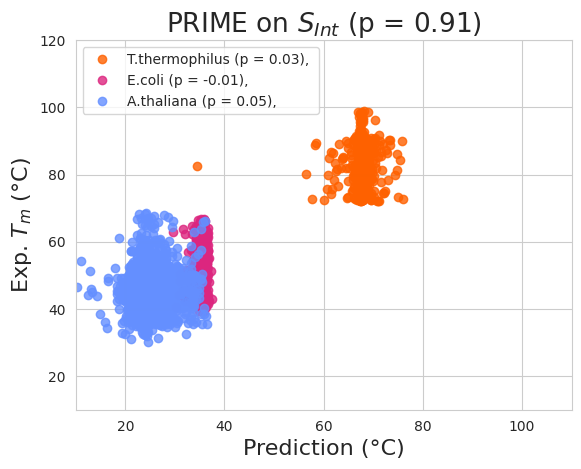

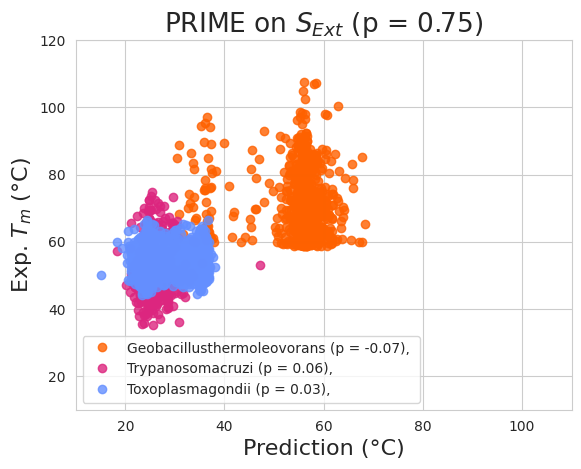

ThermoFormer (lost 0 due to NA)


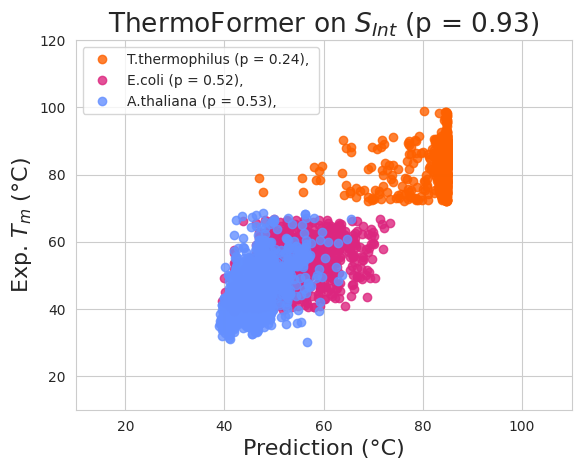

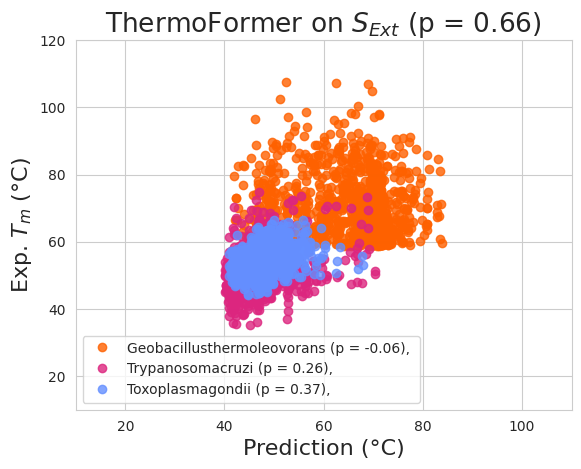

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

color_palettes = {'blue': '#648FFF', 'purple': '#785EF0', 'pink': '#DC267F', 'orange': '#FE6100', 'yellow': '#FE6100'}
colors = [color_palettes['orange'], color_palettes['pink'], color_palettes['blue'],]

# Make TPP plots showing correlation perorganisms

# refers to S_int and S_ext from the paper
test_species = {
    '$S_{Int}$':
        ['T.thermophilus',
        'E.coli',
        'A.thaliana'], 
    '$S_{Ext}$':
        ['Geobacillusthermoleovorans',
        'Trypanosomacruzi',
        'Toxoplasmagondii']
}

models_to_check = [
    'TemBERTure',
    'TmProt',
    'PRIME',
    'ThermoFormer'
]

for mod in models_to_check:
    big_results = pd.read_csv(f'./results/{mod}/1_TEST.csv')
    l = len(big_results)
    big_results = big_results.dropna()
    print(mod, f'(lost {l - len(big_results)} due to NA)')
    name_2_pred = big_results.set_index('name').to_dict()['pred']
    name_2_exp = big_results.set_index('name').to_dict()['exp_tm']
    for sp_group in test_species:
        all_preds = []
        all_exp = []
        for sp_i, sp in enumerate(test_species[sp_group]):
            names_in_this_sp = [name for name in big_results['name'] if big_fasta_labels[name]['sp'] == sp]
            predictions_in_this_sp = [name_2_pred[name] for name in names_in_this_sp]
            exp_values = [name_2_exp[name] for name in names_in_this_sp]
            all_exp += exp_values
            all_preds += predictions_in_this_sp
            corr, p = pearsonr(predictions_in_this_sp, exp_values)
            plt.plot(predictions_in_this_sp, exp_values, 'o', label = f"{sp} (p = {round(corr, 2)}), ", alpha = 0.8, color = colors[sp_i])
        global_corr, p = pearsonr(all_preds, all_exp)
        plt.title(f'{mod} on {sp_group} (p = {round(global_corr, 2)})', fontsize = 19)
        plt.legend()
        plt.xlim(10,110)
        plt.ylim(10,120)
        plt.xlabel('Prediction (°C)', fontsize = 16)
        plt.ylabel('Exp. $T_m$ (°C)', fontsize = 16)
        plt.show()